In [10]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from skmap.misc import find_files, GoogleSheet, ttprint
import warnings
import multiprocess as mp
import time
from scipy.special import expit, logit
import warnings
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, cross_val_score, HalvingGridSearchCV, KFold, GroupKFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
import joblib
import pickle
from sklearn.metrics import r2_score, mean_squared_error, make_scorer#, root_mean_squared_error
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
# from cubist import Cubist
from sklearn.base import BaseEstimator, TransformerMixin
from pathlib import Path
from trees_rf import TreesRandomForestRegressor
from model_fit import read_features, cfi_calc, parameter_fine_tuning, calc_ccc, separate_data, rscfi 
from model_fit import accuracy_plot, plot_top_features, pdp_hexbin, plot_histogram, calc_metrics, accuracy_strata_plot, accuracy_plot_pred_space, calc_metrics_modified
import warnings
from sklearn.inspection import permutation_importance
warnings.filterwarnings('ignore')
import os
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import json
from datetime import datetime

folder_path = '/mnt/ripley/global_soc/scikit-map/global-soil-mapping'
# prop_list = ['ocd', 'soc', 'bulk.density', 'ph.h2o' ,'coarse']
prop_list = ['ocd', 'soc', 'ph.h2o']

transforms_dict = {
    'ocd': 'log1p',
    'soc': 'log1p',
    'bulk.density': None,
    'ph.h2o': None,
    'coarse': 'log1p'
}
version = '20250204'


# Filter data for dependency plot 

In [4]:
test = pd.read_parquet(f'/mnt/ripley/global_soc/scikit-map/global-soil-mapping/ocd/data_test_ocd_v{version}.pq')
cal = pd.read_parquet(f'/mnt/ripley/global_soc/scikit-map/global-soil-mapping/ocd/data_cal_ocd_v{version}.pq')
train = pd.read_parquet(f'/mnt/ripley/global_soc/scikit-map/global-soil-mapping/ocd/data_train_ocd_v{version}.pq')

In [3]:
test.head(3)

,olc_id,site_key,source_db,year,hzn_dep,hzn_top,hzn_bot,ph.h2o,soc,ocd,...,bare.rock_glc.gfz_p_1km_s_2015_2018_go_epsg4326_v20241017,snow.prob_esacci.oct_p90_500m_s_20000101_20121231_go_epsg.4326_v2.0,lon,lat,clm_class,texture1,texture2,hzn_dep_bin,tile_id,ocd_log1p
578990,86FHRCP6+M8J,33,Potash_et_al_2023,2021,37.5,30.0,45.0,NaN,16.9,17.29,...,0.0,0.0,-88.589245,39.836714,snow fully humid hot summer,NaN,NaN,30-60,44610,2.906354
231707,93MJJQP6+V6M,ultras_1263,GLanCE.points,2009,15.0,0.0,30.0,NaN,0.0,0.00,...,100.0,100.0,-147.239444,63.637222,polar frost,NaN,NaN,0-30,54597,0.000000
347943,7H9MW8RP+J6M,03_25_00_1_870859_1999_2018,GLanCE.points,2012,15.0,0.0,30.0,NaN,0.0,0.00,...,0.0,0.0,53.335557,17.941599,hot desert,1.0,0.0,0-30,35146,0.000000


In [7]:
import pandas as pd

df = pd.concat([test, train, cal], axis=0)
df = df[df['ocd'] != 0]

columns_to_keep = [
    'ocd',
    'hzn_dep',
    'clm_lst_mod11a2.nighttime_p50_1km_s0..0cm_YYYY.01.01..YYYY.01.31_v1.2',
    'gpw_ugpp_lue.model_m_30m_s_YYYY0101_YYYY1231_go_epsg.4326_v1'
]
df = df[columns_to_keep]

df = df.reset_index(drop=True)
df.to_parquet(f'data_combined_filtered_ocd_v{version}.pq')


In [2]:
# # Get points in a geopackage
# from shapely.geometry import Point
# import geopandas as gpd
# test = pd.read_parquet(f'/mnt/primus/xuemeng_tmp_harbour/global-soil-mapping/ocd/data_test_ocd_v{version}.pq')

# test['geometry'] = test.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
# points = gpd.GeoDataFrame(test, geometry='geometry')
# points['hzn_dep_bin'] = points['hzn_dep_bin'].astype(str)

# points.to_file(f"data_test_ocd_v{version}.gpkg", driver="GPKG")


# Model evaluation
### generate predictions for evaluation

In [3]:
from sklearn.model_selection import LeaveOneGroupOut

for prop in prop_list:
    print(f'\n{prop}--------------------------------------------------------------')
    space = transforms_dict[prop]
    output_folder = folder_path+'/'+prop
    os.makedirs(output_folder, exist_ok=True)
    
    if space=='log1p':
        # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_log1p'
    elif space=='boxcox':
        # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_boxcox'
        cal[f'{prop}_boxcox'], fitted_lambda = boxcox(cal['ocd'], lmbda=None)
    else:
        tgt = prop
    
    # read in material--------------------------------------------------------------
    # data
    train = pd.read_parquet(f'{output_folder}/data_train_{prop}_v{version}.pq')
    test = pd.read_parquet(f'{output_folder}/data_test_{prop}_v{version}.pq')
    covs = read_features(f'{output_folder}/feature_selected_{prop}_v{version}.txt') # read in
    test[covs] = test[covs].fillna(test[covs].median())
    train[covs] = train[covs].fillna(train[covs].median())
    # test = test.dropna(subset=covs,how='any')
    # train = train.dropna(subset=covs,how='any')
    
    # feature importance
    fi_df = pd.DataFrame(covs, columns=['feature'])
    
    # models
    model_list = find_files(folder_path+f'/{prop}',f'*model*rf*{prop}*joblib')
    model_list = [str(i) for i in model_list]
    keep_col_cv = ['olc_id', 'site_key', 'source_db','year', 'hzn_dep', 'hzn_dep_bin', 'lat', 'lon', 
                'clm_class', 'clm_code', prop, tgt]
    keep_col_test = ['olc_id', 'site_key', 'source_db','year', 'hzn_dep', 'hzn_dep_bin', 'lat', 'lon', 
                'clm_class', 'clm_code', prop, tgt]
    for model_id in model_list:
        model = joblib.load(model_id)
        model.n_jobs = 90
        model_name = model_id.split('_')[-2].split('.')[0]
    
        # cross validation------------------------------------------------------------
        # spatial cv
        cv = GroupKFold(n_splits=5) 
        ttprint(f'start spatial CV for {model_name}')
        y_scv = cross_val_predict(model, train[covs], train[tgt], cv=cv, groups=train['tile_id'])
        ttprint(f'finish temporal CV for {model_name}')
        train[f'{tgt}_cv.spatial_{model_name}'] = y_scv

        # temporal cv
        tgroups = train['year']
        logo = LeaveOneGroupOut()
        ttprint(f'\nstart temporal CV for {model_name}')
        y_tcv = cross_val_predict(model, train[covs], train[tgt], cv=logo.split(train[covs], train[tgt], tgroups))
        ttprint(f'finish temporal CV for {model_name}')
        train[f'{tgt}_cv.loyo_{model_name}'] = y_tcv

        # test---------------------------------------------------------------------------
        ttprint(f'start test prediction for {model_name}')
        model.fit(train[covs], train[tgt])
        y_val = model.predict(test[covs])
        ttprint(f'finish test prediction for {model_name}')
        test[f'{tgt}_test_{model_name}'] = y_val
        
        # variable importance
        pfi = permutation_importance(model, test[covs], test[tgt], n_jobs=80, n_repeats=10, random_state=42)
        fi_df[f'{model_name} permutation importance'] = pfi.importances_mean
        
        
        keep_col_cv = keep_col_cv + [f'{tgt}_cv.loyo_{model_name}', f'{tgt}_cv.spatial_{model_name}']
        keep_col_test = keep_col_test + [f'{tgt}_test_{model_name}']
        
    # save
    # date_str = datetime.today().strftime('%Y%m%d')
    fi_df.to_csv(f'{output_folder}/feature_importance_v{version}.csv',index=False)
    train[keep_col_cv].to_csv(f'{output_folder}/prediction_cv_v{version}.csv',index=False)
    test[keep_col_test].to_csv(f'{output_folder}/prediction_test_{prop}_v{version}.csv',index=False)

## Remove pseudo point with 0 organic carbon to assess accuracy

In [38]:
from sklearn.model_selection import LeaveOneGroupOut

for prop in prop_list:
    print(f'\n{prop}--------------------------------------------------------------')
    space = transforms_dict[prop]
    output_folder = folder_path+'/'+prop
    os.makedirs(output_folder, exist_ok=True)
    
    if space=='log1p':
        # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_log1p'
    elif space=='boxcox':
        # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_boxcox'
        cal[f'{prop}_boxcox'], fitted_lambda = boxcox(cal['ocd'], lmbda=None)
    else:
        tgt = prop
    
    # read in material--------------------------------------------------------------
    # data
    train = pd.read_parquet(f'{output_folder}/data_train_{prop}_v{version}.pq')
    test = pd.read_parquet(f'{output_folder}/data_test_{prop}_v{version}.pq')
    covs = read_features(f'{output_folder}/feature_selected_{prop}_v{version}.txt') # read in
    test[covs] = test[covs].fillna(test[covs].median())
    train[covs] = train[covs].fillna(train[covs].median())
    # test = test.dropna(subset=covs,how='any')
    # train = train.dropna(subset=covs,how='any')
    
    # feature importance
    fi_df = pd.DataFrame(covs, columns=['feature'])
    
    # models
    model_list = find_files(folder_path+f'/{prop}',f'*model*rf*{prop}*joblib')
    model_list = [str(i) for i in model_list]
    keep_col_cv = ['olc_id', 'site_key', 'source_db','year', 'hzn_dep', 'hzn_dep_bin', 'lat', 'lon', 
                'clm_class', 'clm_code', prop, tgt]
    keep_col_test = ['olc_id', 'site_key', 'source_db','year', 'hzn_dep', 'hzn_dep_bin', 'lat', 'lon', 
                'clm_class', 'clm_code', prop, tgt]
    for model_id in model_list:
        model = joblib.load(model_id)
        model.n_jobs = 90
        model_name = model_id.split('_')[-2].split('.')[0]
    
        # cross validation------------------------------------------------------------
        # spatial cv
        cv = GroupKFold(n_splits=5) 
        ttprint(f'start spatial CV for {model_name}')
        y_scv = cross_val_predict(model, train[covs], train[tgt], cv=cv, groups=train['tile_id'])
        ttprint(f'finish temporal CV for {model_name}')

        # temporal cv
        tgroups = train['year']
        logo = LeaveOneGroupOut()
        ttprint(f'\nstart temporal CV for {model_name}')
        y_tcv = cross_val_predict(model, train[covs], train[tgt], cv=logo.split(train[covs], train[tgt], tgroups))
        ttprint(f'finish temporal CV for {model_name}')
        

        # test---------------------------------------------------------------------------
        ttprint(f'start test prediction for {model_name}')
        model.fit(train[covs], train[tgt])
        y_val = model.predict(test[covs])
        ttprint(f'finish test prediction for {model_name}')
        test[f'{tgt}_test_{model_name}'] = y_val
        
        
        train[f'{tgt}_cv.loyo_{model_name}'] = y_tcv
        train[f'{tgt}_cv.spatial_{model_name}'] = y_scv
        
        # variable importance
        pfi = permutation_importance(model, test[covs], test[tgt], n_jobs=80, n_repeats=10, random_state=42)
        fi_df[f'{model_name} permutation importance'] = pfi.importances_mean
        
        
        keep_col_cv = keep_col_cv + [f'{tgt}_cv.loyo_{model_name}', f'{tgt}_cv.spatial_{model_name}']
        keep_col_test = keep_col_test + [f'{tgt}_test_{model_name}']
        
    if (prop == 'ocd') or (prop == 'soc'):
        test = test[test[prop] != 0]
        train = train[train[prop] != 0]
    
    # save
    # date_str = datetime.today().strftime('%Y%m%d')
    fi_df.to_csv(f'{output_folder}/feature_importance_v{version}.csv',index=False)
    train[keep_col_cv].to_csv(f'{output_folder}/prediction_cv_v{version}.csv',index=False)
    test[keep_col_test].to_csv(f'{output_folder}/prediction_test_{prop}_v{version}.csv',index=False)


ph.h2o--------------------------------------------------------------
[15:21:19] start spatial CV for ccc
[15:22:17] finish temporal CV for ccc
[15:22:17] 
start temporal CV for ccc
[15:27:43] finish temporal CV for ccc
[15:27:43] start test prediction for ccc
[15:27:58] finish test prediction for ccc


In [47]:
for prop in prop_list:
    output_folder = folder_path+'/'+prop
    csv_path = f'{output_folder}/feature_importance_v{version}.csv'
    df = pd.read_csv(csv_path)
    df_sorted = df.sort_values(by="ccc permutation importance", ascending=False)
    df_sorted = df_sorted.reset_index(drop=True)
    df_sorted.to_csv(f'{output_folder}/{prop}_feature_importance_v{version}.csv',index=False)


## Calculate metrics and plot accuracy figure

In [146]:
import os
import numpy as np
import matplotlib.pyplot as plt
from cmcrameri import cm
import math
from matplotlib.ticker import FuncFormatter  # Added

cmap = cm.batlow_r  
cmap.set_bad(color="#F8F8FF")
             
def accuracy_plot_orig_space(y_test, y_pred, prop, space, mdl, test_type, data_path):
    # Back-transform if necessary
    if (prop == 'ocd') or (prop == 'soc'):
        y_test_orig = np.expm1(y_test)
        y_pred_orig = np.expm1(y_pred)
        p = 1.5
    elif prop == 'ph.h2o':
        y_test_orig = y_test
        y_pred_orig = y_pred
        p = 0
    else:
        raise Exception(f"Method not implemented for properites {prop}")
    
    rmse, mae, medae, mape, _, _, bias = calc_metrics_modified(y_test_orig, y_pred_orig)
    _, _, _, _, ccc, r2, _ = calc_metrics_modified(y_test, y_pred)

    # Filter out negative or nan values for plotting
    mask = np.isfinite(y_test) & np.isfinite(y_pred)
    y_test = y_test[mask]
    y_pred = y_pred[mask]
    
    mask = (y_test_orig>0) & (y_pred_orig>0)
    y_test_orig = y_test_orig[mask]
    y_pred_orig = y_pred_orig[mask]
    
    d2 = d2_tweedie_score(y_test_orig, y_pred_orig, power=p)
    
    # Define plot limits
    show_range = [
        math.floor(np.min([y_test.min(), y_pred.min()])),
        math.ceil(np.max([y_test.max(), y_pred.max()]))
    ]

    # Set up figure
    plt.rcParams.update({'font.size': 16})
    fig, ax = plt.subplots(figsize=(8, 7))
    
    test_type
    
    test_type_dict = {
        'cv.loyo': 'Temporal cross validation',
        'cv.spatial': 'Spatial cross validation',
        'test': 'Stratified testing',
    }
    prop_dict = {
        'ocd': r'SOC density [kg m$^{{-3}}$]',
        'soc': f'SOC content [g kg$^{{-1}}$]',
        'ph.h2o': r'$pH_{{H2O}}$',
    }
    
    test_type_str = test_type_dict[test_type]
    prop_str = prop_dict[prop]

    if (prop == 'ocd') or (prop == 'soc'):
        ax.set_title(
        rf"{test_type_str} using {len(y_test):,} samples"
            "\n"
            rf"RMSE = {rmse:.2f}, $D^2_{{p=1.5}} = {d2:.2f},\ CCC_{{\log(1 + x)}} = {ccc:.2f}$"
        )
    elif prop == 'ph.h2o':
        ax.set_title(
        rf"{test_type_str} using {len(y_test):,} samples"
            "\n"
            rf"RMSE = {rmse:.2f}, $D^2_{{p=0}} = {d2:.2f},\ CCC = {ccc:.2f}$"
        )

    hb = ax.hexbin(y_pred, y_test, gridsize=(20, 20), cmap=cmap, mincnt=1, bins='log')

    ax.set_xlabel(f'Predicted {prop_str}')
    ax.set_ylabel(f'Observed {prop_str}')
    ax.set_aspect('auto', adjustable='box')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.plot(show_range, show_range, "-k", alpha=.5)

    if (prop == 'ocd') or (prop == 'soc'):
        powers = np.arange(0, 4)  # 10^0 to 10^3 → [1, 10, 100, 1000]
        tick_vals = np.log1p(10**powers)
        ax.set_xticks(tick_vals)
        ax.set_yticks(tick_vals)
        def expm1_formatter(x, _):
            return f'{np.expm1(x):.0f}'
        ax.xaxis.set_major_formatter(FuncFormatter(expm1_formatter))
        ax.yaxis.set_major_formatter(FuncFormatter(expm1_formatter))

    # Create colorbar
    cax = fig.add_axes([ax.get_position().x1 + 0.05, ax.get_position().y0, 0.02, ax.get_position().height])
    cb = fig.colorbar(hb, cax=cax)
    cb.set_label('Count')

    plt.tight_layout(rect=[0, 0, 0.92, 1])  # Adjust the right margin to make room for colorbar
    plt.savefig(f'{data_path}/{prop}/plot_accuracy.{space}.{test_type}_{mdl}.{prop}.pdf', format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()
    
    return rmse, mae, medae, mape, ccc, r2, bias, d2


## Plot accuracy plots


ocd--------------------------------------------------------------


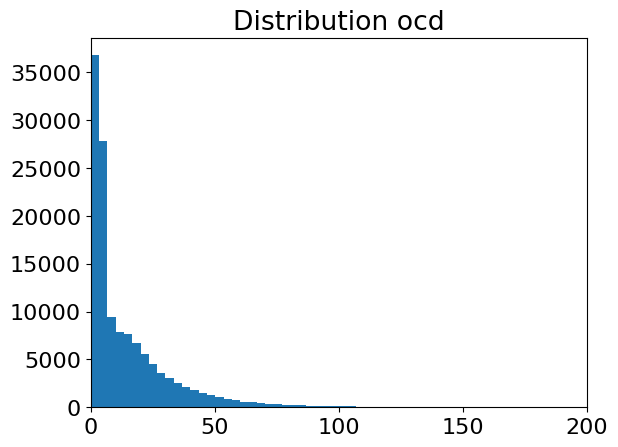

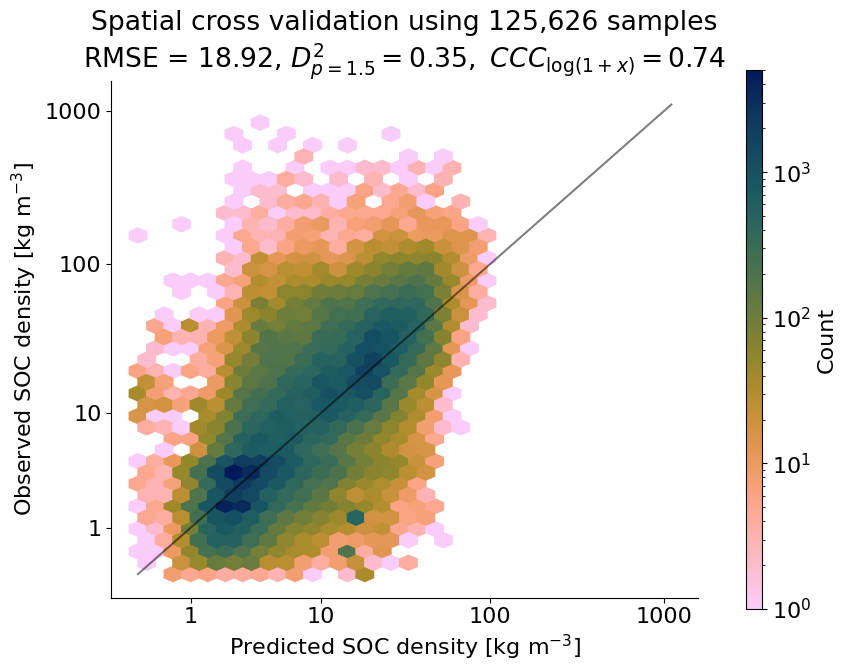

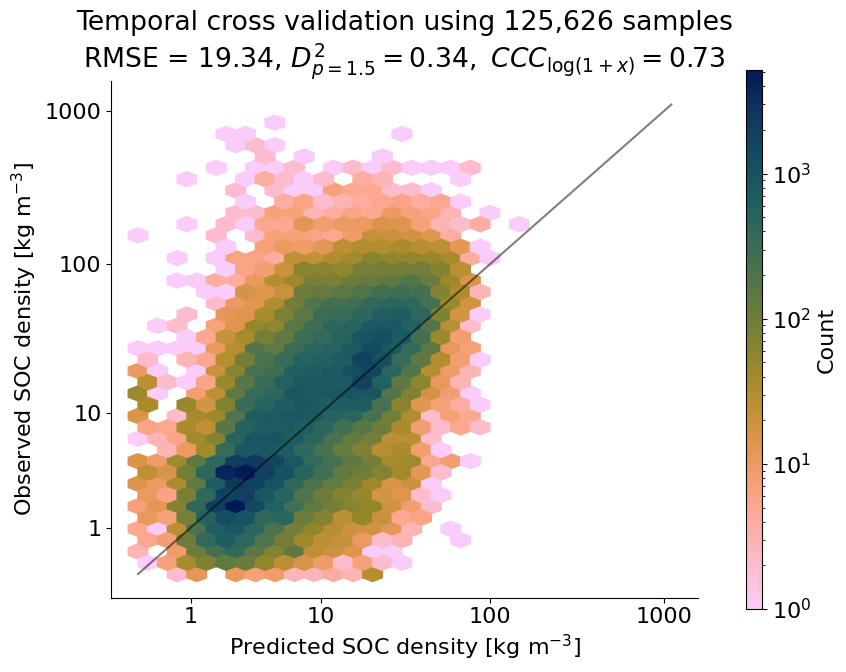

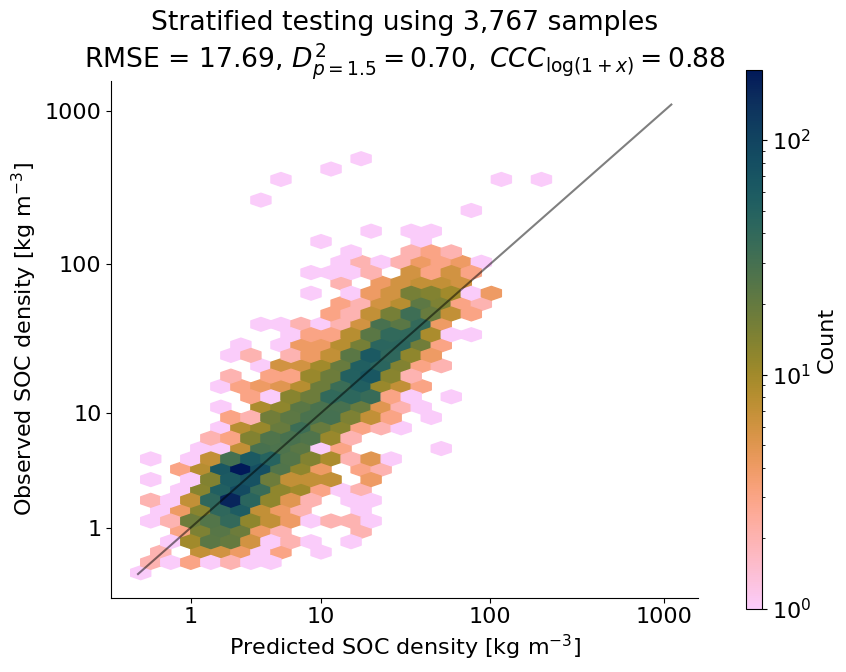


soc--------------------------------------------------------------


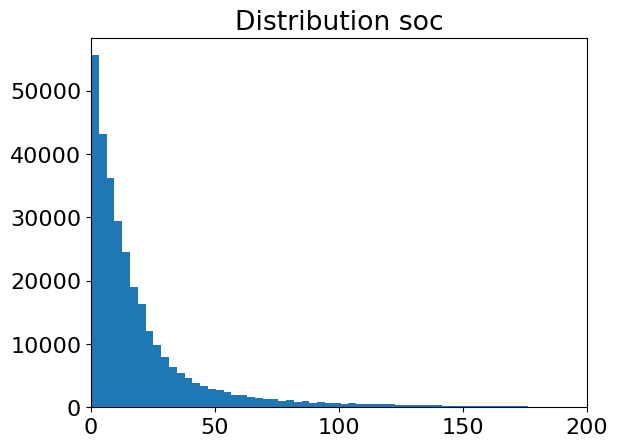

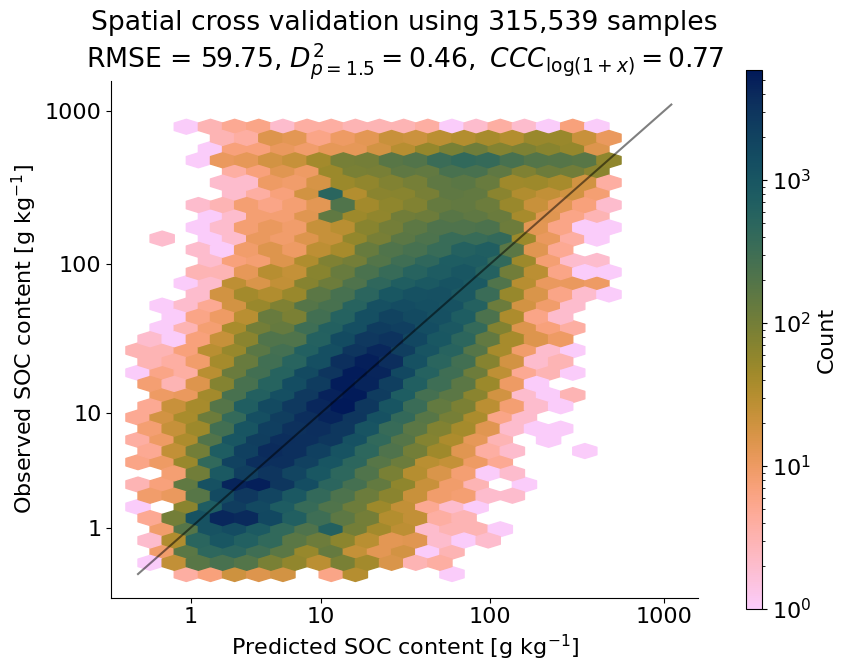

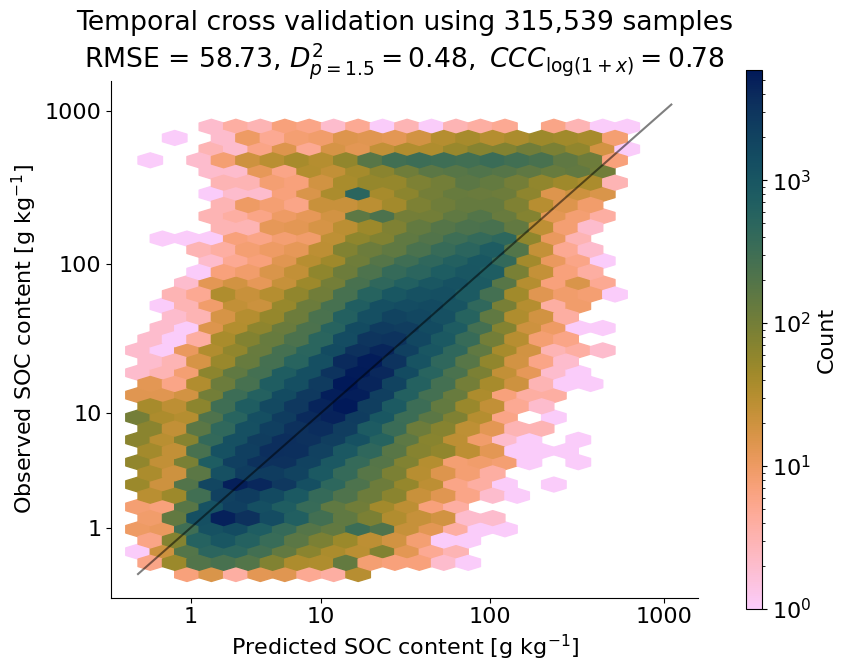

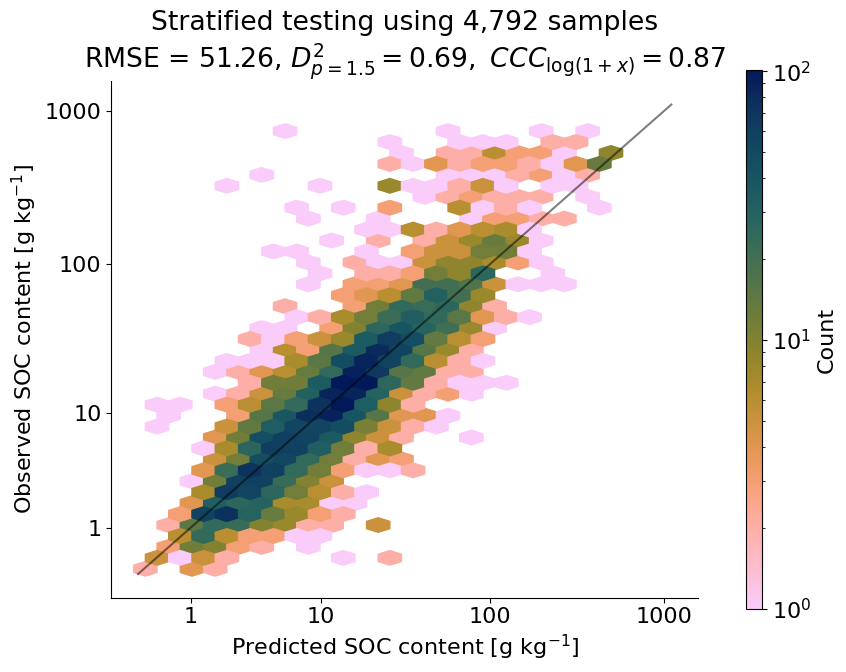


ph.h2o--------------------------------------------------------------


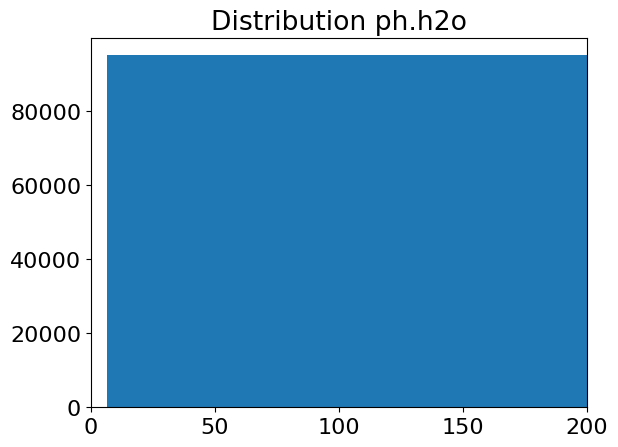

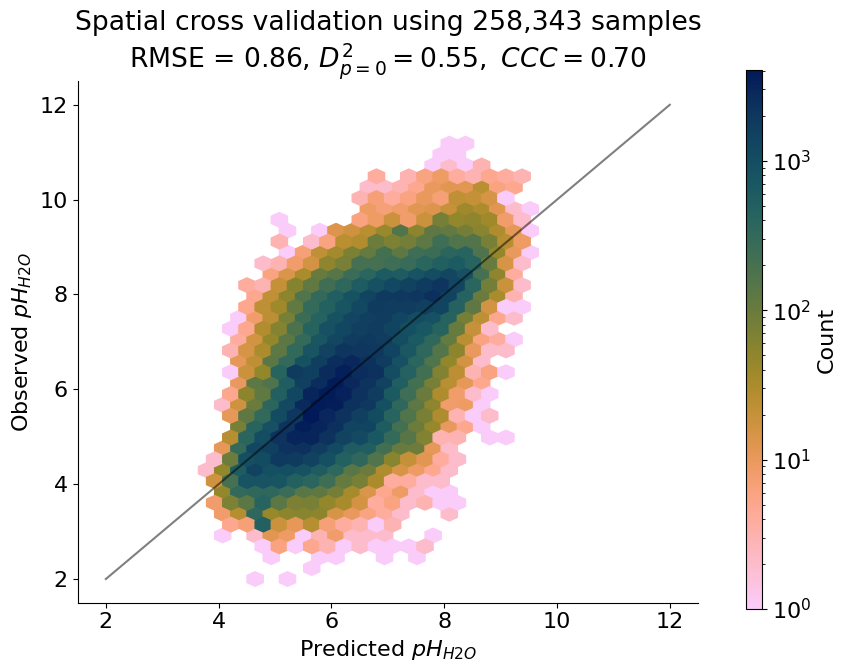

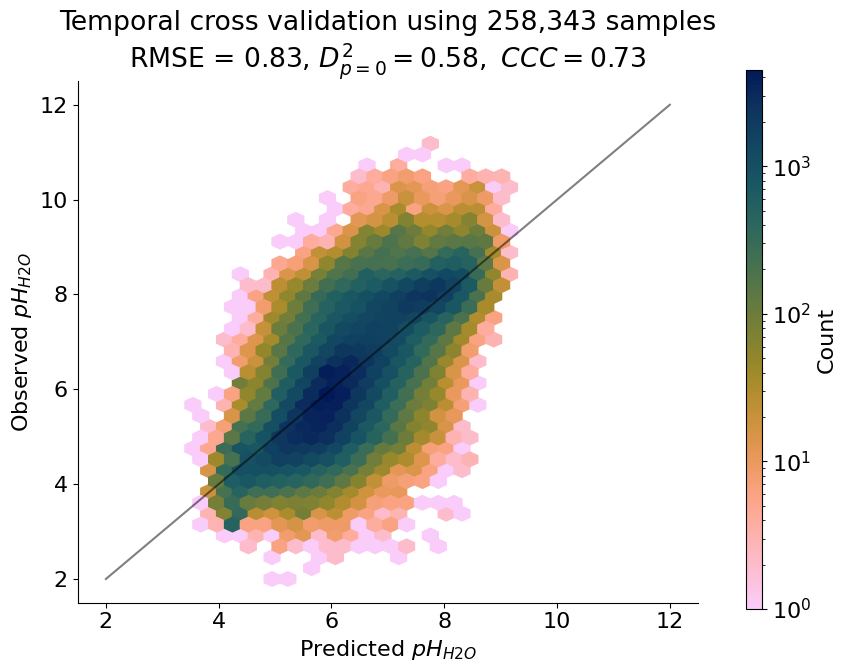

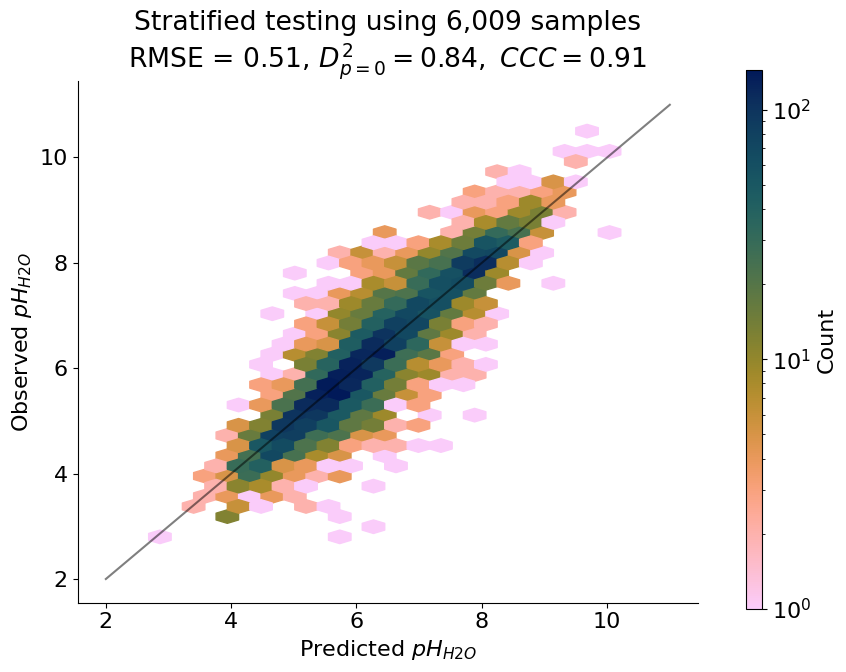

In [147]:
# general accuracy

results_cv = []

for prop in prop_list:
    print(f'\n{prop}--------------------------------------------------------------')
    space = transforms_dict[prop]
    output_folder = folder_path+'/'+prop
    os.makedirs(output_folder, exist_ok=True)
    
    if space=='log1p':
        # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_log1p'
    elif space=='boxcox':
        # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_boxcox'
        cal[f'{prop}_boxcox'], fitted_lambda = boxcox(cal['ocd'], lmbda=None)
    else:
        tgt = prop
    
    # read in data--------------------------------------------------------------
    train = pd.read_csv(f'{output_folder}/prediction_cv_v{version}.csv')
    test = pd.read_csv(f'{output_folder}/prediction_test_{prop}_v{version}.csv')
    y_ref = np.expm1(np.concatenate([train[tgt].to_numpy(), test[tgt].to_numpy()]))

    plt.hist(y_ref, bins=250)
    plt.title(f'Distribution {prop}')
    plt.xlim([0,200])
    plt.show()

        
    # accuracy plot
    model_list = find_files(folder_path+f'/{prop}',f'*model*rf*{prop}*joblib')
    model_list = [str(i) for i in model_list]
    
    for model_id in model_list:
        mdl = model_id.split('_')[-2].split('.')[0]
        for test_type in ['cv.spatial', 'cv.loyo']:
            rmse, mae, medae, mape, ccc, r2, bias, d2 = accuracy_plot_orig_space(train[tgt], train[f'{tgt}_{test_type}_{mdl}'], 
                                                                             prop, space, mdl, test_type, folder_path)
            results_cv.append({
                'prop':prop,
                'model': mdl,
                'evaluation_type': test_type,
                'RMSE': rmse,
                'MAE': mae,
                'MedAE': medae,
                'MAPE': mape,
                'R2': r2,
                'CCC': ccc,
                'bias': bias
            })

        # rmse, mae, medae, mape, ccc, r2, bias = accuracy_plot_pred_space(test_nozero[tgt], test_nozero[f'{tgt}_test_{mdl}'],
        #                                                                prop, space, mdl, 'test', folder_path)
        rmse, mae, medae, mape, ccc, r2, bias, d2 = accuracy_plot_orig_space(test[tgt], test[f'{tgt}_test_{mdl}'],
                                                                       prop, space, mdl, 'test', folder_path)
        results_cv.append({
            'prop':prop,
            'model': mdl,
            'evaluation_type': 'test',
            'RMSE': rmse,
            'MAE': mae,
            'MedAE': medae,
            'MAPE': mape,
            'R2': r2,
            'CCC': ccc,
            'bias': bias
        })

     
        
        
    
results_cv = pd.DataFrame(results_cv)
results_cv.to_csv(f'{folder_path}/material/metrics_all.prop_{version}.csv',index=False)

### plot test accuracies by strata

In [134]:
bins = [0, 30, 60, 100, float('inf')]
labels = ['0-30', '30-60', '60-100', '>100']  

In [135]:
# strata accuracy
for prop in prop_list:
    print(f'\n{prop}--------------------------------------------------------------')
    space = transforms_dict[prop]
    output_folder = folder_path+'/'+prop
    os.makedirs(output_folder, exist_ok=True)
    
    if space=='log1p':
        # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_log1p'
    elif space=='boxcox':
        # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_boxcox'
        cal[f'{prop}_boxcox'], fitted_lambda = boxcox(cal['ocd'], lmbda=None)
    else:
        tgt = prop
    
    test = pd.read_csv(f'{output_folder}/prediction_test_{prop}_v{version}.csv')
    test['hzn_dep_bin'] = pd.cut(test['hzn_dep'], bins=bins, labels=labels, right=True)
    
    # accuracy plot
    model_list = find_files(folder_path+f'/{prop}',f'*model*rf*{prop}*joblib')
    model_list = [str(i) for i in model_list]

    for model_id in model_list:
        model = joblib.load(model_id)   
        stratified_results = []

        for clm in test['clm_class'].unique():
            for z_bin in test['hzn_dep_bin'].unique():
                subset = test[(test['clm_class'] == clm) & (test['hzn_dep_bin'] == z_bin)]

                if len(subset) == 0:
                    continue  # Skip if the subset is empty

                # y_val_strata = model.predict(subset[covs])
                y_val_strata = subset[f'{tgt}_test_{mdl}']
                rmse_val, mae_val, medae_val, mape_val, ccc_val, r2_val, bias_val = calc_metrics(subset[tgt], y_val_strata, space=space)
                stratified_results.append({
                    'model': mdl,
                    'stratum_type': 'clm_class + hzn_dep_bin',
                    'clm_class': clm,
                    'hzn_dep_bin': z_bin,
                    'RMSE': rmse_val,
                    'MAE': mae_val,
                    'MAPE': mape_val,
                    'MedAE': medae_val,
                    'R2': np.nan if len(subset)<5 else r2_val,
                    'CCC': np.nan if len(subset)<5 else ccc_val,
                    'bias': bias_val,
                    'count': len(subset) 
                })
            
    stratified_results_df = pd.DataFrame(stratified_results)
    stratified_results_df.to_csv(f'{output_folder}/metrics_test.strata_{prop}_{version}.csv',index=False)
    


ocd--------------------------------------------------------------

soc--------------------------------------------------------------

ph.h2o--------------------------------------------------------------


In [ ]:
prop = 'ocd'
mdl = 'rf'
stratified_results_df = pd.read_csv(f'{folder_path}/{prop}/metrics_test.strata_{prop}_{version}.csv')
strata_df = stratified_results_df.loc[stratified_results_df['model'] == mdl]

In [ ]:
import seaborn as sns
def accuracy_strata_plot(metric, strata_df, prop, mdl):

    plt.figure(figsize=(12, 10))
    pivot_data = strata_df.pivot(index='clm_class', columns='hzn_dep_bin', values=metric)

    pivot_data = pivot_data.reindex(['0-30', '30-60', '60-100', '>100'],axis=1)

    ax = sns.heatmap(
        pivot_data,
        annot=True,
        fmt=".2f",
        cmap='autumn_r',
        cbar_kws={
            'shrink': 0.7, 
            'label': metric
        },
        annot_kws={"fontsize": 13},
        vmin = 1,
        vmax = 20
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=14)  # Font size for colorbar ticks
    cbar.set_label(metric, size=14)  # Font size for colorbar label

    for i in range(pivot_data.shape[0] + 1):  # Horizontal grid lines
        ax.axhline(i, color='black', linewidth=1)
    for j in range(pivot_data.shape[1] + 1):  # Vertical grid lines
        ax.axvline(j, color='black', linewidth=1)

    ax.set_title(f'{prop}, {mdl}, {metric}', fontsize=14)
    ax.set_xlabel('Soil depth (cm)', fontsize=14)
    ax.set_ylabel('Climate class', fontsize=14)

    # ax.set_xticks(np.arange(len(pivot_data.columns)) + 0.7)
    ax.set_xticklabels(pivot_data.columns, fontsize=14) #, ha='right'
    ax.set_yticklabels(pivot_data.index, fontsize=14) #rotation=60,

    plt.tight_layout()
    plt.show()

In [ ]:
accuracy_strata_plot('RMSE', strata_df, prop, mdl)